# Linear analysis of supraglacial stream incision

For a land-based ice layer of uniform thickness subjected to surface melting ($m$),
a linearised model for evolution of the topography perturbation ($\Delta h$)
is given in terms of the scaled wavevector magnitude $k = H|\pmb{k}|$
$$\frac{\partial \widehat{\Delta h}}{\partial t}=-\frac{\rho_\mathrm{i}g\bar{H}}{2\eta}\mathsf{R}\widehat{\Delta h} - \widehat{m} \tag{$\bigstar$}$$
where  $\bar{H}$ is the initial ice thickness, $\eta$ is the (Newtonian)
ice viscosity,
and $\mathsf{R}$ is the topographic relaxation function that is given by
$$
\mathsf{R} = \frac{1}{ k}\frac{ (k+\gamma)e^{4{k}} -(2+4\gamma  ){k}e^{2{k}} +k-\gamma  }{ \left(k+{\gamma}\right) e^{4
 k} + 2\left({\gamma}  + 2 ({1+\gamma}) k^{2}  \right) e^{2 k} - \left(k-{\gamma}\right)}, 
$$
with $\gamma ={\beta\overline{H}}/({2\eta})$ ($\beta$ is basal sliding coefficient).

Equation ($\bigstar$) is an exponential decay equation (for each wavenumber $k$ in Fourier space) that is forced by the surface melting rate. 

For simplicity, in the limit of no basal sliding $\gamma\to\infty$, $\mathsf{R}$ reduces to: 
$$
\mathsf{R} = \frac{1}{ k}\frac{ e^{4{k}} - 4{k}e^{2{k}} - 1 }{ 
    e^{4k} + 2( 1 + 2k^{2})  e^{2 k} + 1}, \tag{$\gamma\to\infty$}
$$

Steady solutions (equilibrium) are given by 

$$\widehat{\Delta h}_\mathrm{e}  = - \frac{2\eta}{\rho_\mathrm{i}g\bar{H}\mathsf{R}}\widehat{m}$$

Therefore, when surface melting is sinusoidal, the elevation anomaly will also be sinusoidal with an amplitude proportional to $1/\mathsf{R}$ at a given frequency $k$.
Let $m = m_0 \exp(ik_0 x)$ for some magnitude $m_0$ and frequency $k_0$. Then
$\widehat{m} = 2\pi m_0 \delta (k-k_0)$ and we obtain the steady solution for
the depth of incision (note $2\pi$ divided through by inverse transform):
$$|{\Delta h}_\mathrm{e}|  = \frac{2\eta m_0}{\rho_\mathrm{i}g\bar{H}\mathsf{R}(k_0)}
\tag{sinusoids}
$$

An asymptotic approximation in the limit of high frequencies gives $1/\mathsf{R} \sim k$
so that
$$|{\Delta h}_\mathrm{e}| \sim \frac{2\eta m_0 k_0}{\rho_\mathrm{i}g\bar{H}}
\tag{sinusoids, large $k$},
$$
or, in terms of wavelength $\lambda_0 = 2\pi/k_0$:
$$
\boxed{
|{\Delta h}_\mathrm{e}| \sim \frac{4\pi\eta m_0 }{\rho_\mathrm{i}g\bar{H}\lambda_0}
}
$$

We will plot this in Python!

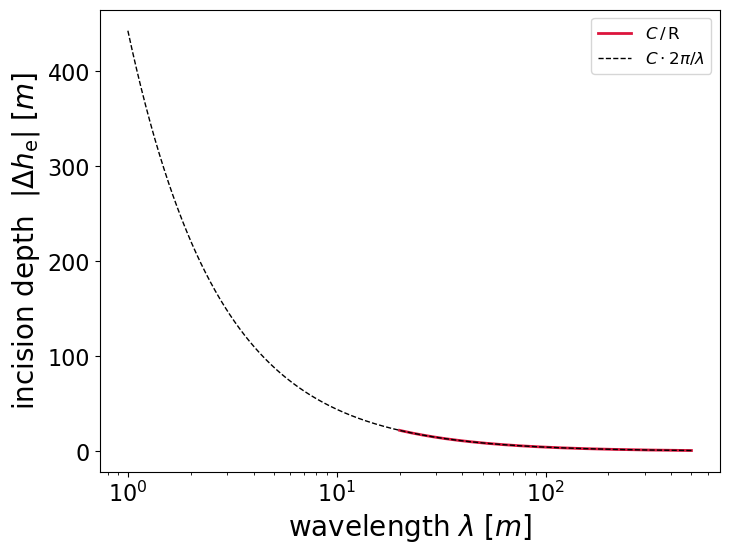

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# define some parameters, change around if you want!
rho_i = 917.0             # ice density [kg/m^3]
g = 9.81                  # gravity [m/s^2]
H = 500                   # initial ice thickness [m]
eta = 1e13                # viscosity [Pa s]
m_0 = 1/3.154e7           # melt rate magnitude [m/s]
C = 2*eta*m_0/(rho_i*g*H) # coefficient on steady solution [s]

def R_inv(k):
    # formula for inverse of topographic relaxation function (R) assuming no sliding at base
    numerator = np.exp(4*k) - 4*k*np.exp(2*k) - 1 
    denominator = k*(np.exp(4*k) + 2*(1 + 2*k**2)*np.exp(2*k) + 1)
    return denominator/numerator 

# we can't go too high with frequency or numpy will complain about R_inv function:
k = np.linspace(1e0,2.5e1,10000)*(2*np.pi) # wavevector magnitude (scaled by H)
lamda = (2*np.pi/k) * H                  # dimensional wavelength [m]

# extend coordinates for asymptotic formula, can go to much smaller wavelengths:
k_ = np.linspace(1e0,5e2,10000)*(2*np.pi)  # wavevector magnitude (scaled by H)
lamda_ = (2*np.pi/k_) * H                  # dimensional wavelength [m]

plt.figure(figsize=(8,6))
plt.plot(lamda,C*R_inv(k),linewidth=2,color='crimson',label=r'$C\,/\,\mathsf{R}$')
plt.plot(lamda_,C*k_,linewidth=1,color='k',linestyle='--',label=r'$C\cdot2\pi/\lambda$')
plt.xlabel(r'wavelength $\lambda$ $[m]$',fontsize=20)
plt.ylabel(r'incision depth  $|\Delta h_\mathrm{e}|$ $[m]$',fontsize=20)
plt.xscale('log')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.show()
plt.close()